In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
event_file = pd.read_csv('data/psi_response.csv')
event_file

,event_id,gene_id,K562_summed_tpm,GM12878_summed_tpm,K562_alt_tpm,GM12878_alt_tpm,K562_gene_level_tpm,GM12878_gene_level_tpm,K562_SE_psi,GM12878_SE_psi
0,ENSG00000224051;SE:chr1:1325102-1326836:132703...,ENSG00000224051,0.499687,1.133219,0.492760,1.120903,0.576341,1.146438,0.983660,0.971831
1,ENSG00000160072;SE:chr1:1486668-1487863:148791...,ENSG00000160072,1.236285,1.539202,1.172019,1.475816,1.344589,1.576687,0.861646,0.863808
2,ENSG00000160072;SE:chr1:1489274-1489692:148981...,ENSG00000160072,1.172019,1.475816,0.611723,0.610660,1.344589,1.576687,0.270325,0.133512
3,ENSG00000197530;SE:chr1:1624901-1624991:162518...,ENSG00000197530,0.220108,0.382017,0.184691,0.359835,0.833147,1.226858,0.916667,0.948052
4,ENSG00000197530;SE:chr1:1625653-1626650:162675...,ENSG00000197530,0.089905,0.120574,0.064458,0.089905,0.833147,1.226858,0.938053,0.926230
...,...,...,...,...,...,...,...,...,...,...
20124,ENSG00000130787;AR:chr12:122848094-122848466:1...,ENSG00000130787,0.793790,0.959041,-1.000000,-1.000000,1.094122,1.214314,1.000000,1.000000
20125,ENSG00000168411;AR:chr16:74652122-74660932:746...,ENSG00000168411,1.736954,1.401401,-1.000000,-1.000000,1.892484,1.588496,1.000000,1.000000
20126,ENSG00000146247;AR:chr6:78946260-78946711:7894...,ENSG00000146247,0.938019,0.976350,-1.000000,-1.000000,0.938019,0.976350,1.000000,1.000000
20127,ENSG00000153113;AR:chr5:96742156-96742655:9674...,ENSG00000153113,-0.366532,-0.698970,-1.000000,-1.000000,1.635584,1.620344,1.000000,1.000000


In [16]:
# filter df by event_id (only keep rows with event_id that contains 'SE')
event_file = event_file[event_file['event_id'].str.contains(';SE:')]
event_file

,event_id,gene_id,K562_summed_tpm,GM12878_summed_tpm,K562_alt_tpm,GM12878_alt_tpm,K562_gene_level_tpm,GM12878_gene_level_tpm,K562_SE_psi,GM12878_SE_psi
0,ENSG00000224051;SE:chr1:1325102-1326836:132703...,ENSG00000224051,0.499687,1.133219,0.492760,1.120903,0.576341,1.146438,0.983660,0.971831
1,ENSG00000160072;SE:chr1:1486668-1487863:148791...,ENSG00000160072,1.236285,1.539202,1.172019,1.475816,1.344589,1.576687,0.861646,0.863808
2,ENSG00000160072;SE:chr1:1489274-1489692:148981...,ENSG00000160072,1.172019,1.475816,0.611723,0.610660,1.344589,1.576687,0.270325,0.133512
3,ENSG00000197530;SE:chr1:1624901-1624991:162518...,ENSG00000197530,0.220108,0.382017,0.184691,0.359835,0.833147,1.226858,0.916667,0.948052
4,ENSG00000197530;SE:chr1:1625653-1626650:162675...,ENSG00000197530,0.089905,0.120574,0.064458,0.089905,0.833147,1.226858,0.938053,0.926230
...,...,...,...,...,...,...,...,...,...,...
7168,ENSG00000071889;SE:chrX:154507490-154507811:15...,ENSG00000071889,1.250908,1.129045,1.177536,1.055760,1.467756,1.265525,0.843679,0.843563
7169,ENSG00000071889;SE:chrX:154511871-154512823:15...,ENSG00000071889,1.091667,1.020361,1.081707,0.988113,1.467756,1.265525,0.977143,0.927746
7170,ENSG00000071889;SE:chrX:154511871-154512314:15...,ENSG00000071889,1.184691,1.080626,0.522444,0.382017,1.467756,1.265525,0.212500,0.193467
7171,ENSG00000130830;SE:chrX:154792285-154799745:15...,ENSG00000130830,2.348324,1.070407,0.453318,-1.000000,2.468805,1.156246,0.012292,0.000000


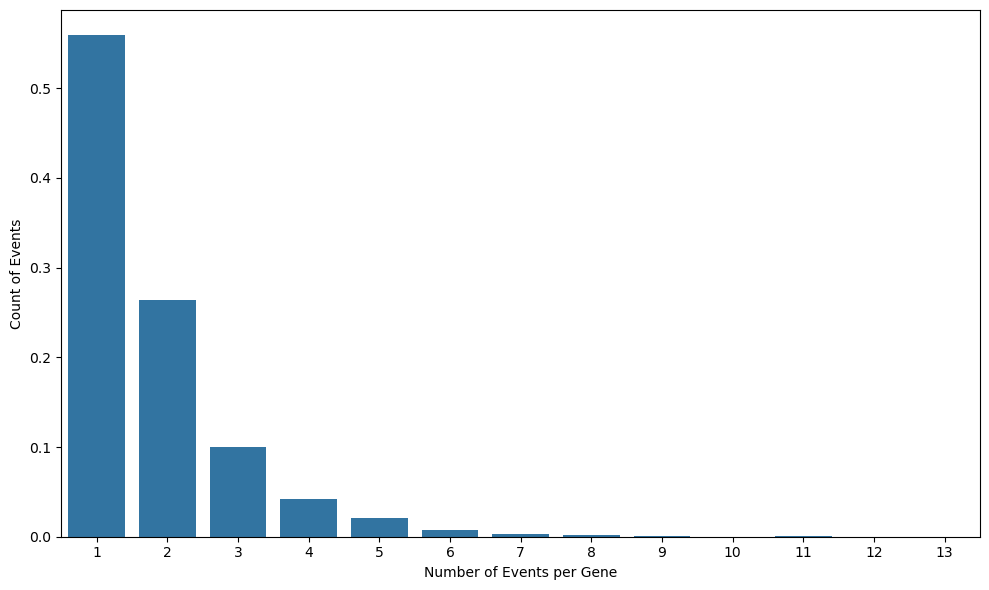

In [18]:
# count by gene_id
event_counts = event_file['gene_id'].value_counts().reset_index()
event_counts.columns = ['gene_id', 'event_count']

event_counts = event_counts['event_count'].value_counts().reset_index()
event_counts['count'] = event_counts['count'] / event_counts['count'].sum()

# plot the counts
plt.figure(figsize=(10, 6))
sns.barplot(x='event_count', y='count', data=event_counts)
plt.xlabel('Number of Events per Gene')
plt.ylabel('Count of Events')
plt.tight_layout()
plt.show()